In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR

warnings.filterwarnings('ignore')

model_results = {}

In [54]:
# ============= Load data =============
print("="*50)
print("LOADING PREPROCESSED DATA")
print("="*50)


X_train = pd.read_csv('../data/X_train_normalized.csv')
X_test = pd.read_csv('../data/X_test_normalized.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

# Convert y to a Series (instead of a DataFrame)
y_train = y_train.squeeze() if y_train.shape[1] == 1 else y_train
y_test = y_test.squeeze() if y_test.shape[1] == 1 else y_test

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("="*50)


LOADING PREPROCESSED DATA
X_train shape: (8325, 207)
X_test shape: (2775, 207)
y_train shape: (8325,)
y_test shape: (2775,)


In [55]:
print("\n" + "="*50)
print("1. Linear Regression")
print("="*50)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

model_results['Linear Regression'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['Linear Regression']['Train R²']:.4f}")
print(f"Test R²: {model_results['Linear Regression']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Linear Regression']['Test MAE']:.4f}")
print(f"Test RMSE: {model_results['Linear Regression']['Test RMSE']:.4f}")


1. Linear Regression
Train R²: 0.9890
Test R²: 0.9637
Test MAE: 0.7289
Test RMSE: 1.2220


In [56]:
# 2. Random Forest 
print("\n" + "="*50)
print("2. Random Forest Regressor (Optimized)")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=15,
    min_samples_leaf=5,
    max_features='sqrt',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

model_results['Random Forest'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['Random Forest']['Train R²']:.4f}")
print(f"Test R²: {model_results['Random Forest']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Random Forest']['Test MAE']:.4f}")
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test RMSE: {model_results['Random Forest']['Test RMSE']:.4f}") 
print(f"OOB Score: {rf_model.oob_score_:.4f}")



2. Random Forest Regressor (Optimized)
Train R²: 0.9805
Test R²: 0.9543
Test MAE: 1.0140
Test RMSE: 1.3716
OOB Score: 0.9739


In [57]:
# 3. Gradient Boosting 
print("\n" + "="*50)
print("3. Gradient Boosting Regressor (Optimized)")
print("="*50)

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    random_state=42
)

gbr_model.fit(X_train, y_train)
y_train_pred = gbr_model.predict(X_train)
y_test_pred = gbr_model.predict(X_test)

model_results['Gradient Boosting'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['Gradient Boosting']['Train R²']:.4f}")
print(f"Test R²: {model_results['Gradient Boosting']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Gradient Boosting']['Test MAE']:.4f}")
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"Test RMSE: {model_results['Gradient Boosting']['Test RMSE']:.4f}") 


3. Gradient Boosting Regressor (Optimized)
Train R²: 0.9985
Test R²: 0.9867
Test MAE: 0.4935
Test RMSE: 0.7386


In [58]:
# 4. Ridge Regression
print("\n" + "="*50)
print("Ridge Regression")
print("="*50)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_train_pred = ridge_model.predict(X_train)
y_test_pred = ridge_model.predict(X_test)

model_results['Ridge Regression'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['Ridge Regression']['Train R²']:.4f}")
print(f"Test R²: {model_results['Ridge Regression']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Ridge Regression']['Test MAE']:.4f}")
print(f"Test RMSE: {model_results['Ridge Regression']['Test RMSE']:.4f}")


Ridge Regression
Train R²: 0.9889
Test R²: 0.9668
Test MAE: 0.6845
Test RMSE: 1.1682


In [59]:
# 5. Lasso Regression
print("\n" + "="*50)
print("Lasso Regression")
print("="*50)

lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000,
    random_state=42
)

lasso_model.fit(X_train, y_train)

y_train_pred = lasso_model.predict(X_train)
y_test_pred = lasso_model.predict(X_test)

model_results['Lasso Regression'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['Lasso Regression']['Train R²']:.4f}")
print(f"Test R²: {model_results['Lasso Regression']['Test R²']:.4f}")
print(f"Test MAE: {model_results['Lasso Regression']['Test MAE']:.4f}")
print(f"Test RMSE: {model_results['Lasso Regression']['Test RMSE']:.4f}")


Lasso Regression
Train R²: 0.9878
Test R²: 0.9670
Test MAE: 0.6685
Test RMSE: 1.1664


In [60]:
# 6. AdaBoost Regressor
print("\n" + "="*50)
print("AdaBoost Regressor")
print("="*50)

ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_train_pred = ada_model.predict(X_train)
y_test_pred = ada_model.predict(X_test)

model_results['AdaBoost'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['AdaBoost']['Train R²']:.4f}")
print(f"Test R²: {model_results['AdaBoost']['Test R²']:.4f}")
print(f"Test MAE: {model_results['AdaBoost']['Test MAE']:.4f}")
print(f"Test RMSE: {model_results['AdaBoost']['Test RMSE']:.4f}")


AdaBoost Regressor
Train R²: 0.9283
Test R²: 0.9007
Test MAE: 1.5594
Test RMSE: 2.0215


In [61]:
# 7. Support Vector Regression (SVR)
print("\n" + "="*50)
print("Support Vector Regression (SVR)")
print("="*50)

svr_model = SVR(
    kernel='rbf',
    C=1000,
    epsilon=0.01,
    gamma='scale'
)

svr_model.fit(X_train, y_train)

y_train_pred = svr_model.predict(X_train)
y_test_pred = svr_model.predict(X_test)

model_results['SVR'] = {
    'Train R²': r2_score(y_train, y_train_pred),
    'Test R²': r2_score(y_test, y_test_pred),
    'Train MSE': mean_squared_error(y_train, y_train_pred),
    'Test MSE': mean_squared_error(y_test, y_test_pred),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_test_pred),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred))
}

print(f"Train R²: {model_results['SVR']['Train R²']:.4f}")
print(f"Test R²: {model_results['SVR']['Test R²']:.4f}")
print(f"Test MAE: {model_results['SVR']['Test MAE']:.4f}")
print(f"Test RMSE: {model_results['SVR']['Test RMSE']:.4f}")


Support Vector Regression (SVR)
Train R²: 0.8710
Test R²: 0.8996
Test MAE: 1.4412
Test RMSE: 2.0332


In [62]:
# ============= 7. Display comparison =============
print("\n" + "="*50)
print("FINAL MODEL COMPARISON")
print("="*50)

comparison_df = pd.DataFrame(model_results).T
print(comparison_df.round(4))



FINAL MODEL COMPARISON
                   Train R²  Test R²  Train MSE  Test MSE  Train MAE  \
Linear Regression    0.9890   0.9637     0.6687    1.4933     0.5160   
Random Forest        0.9805   0.9543     1.1885    1.8812     0.7487   
Gradient Boosting    0.9985   0.9867     0.0935    0.5455     0.2228   
Ridge Regression     0.9889   0.9668     0.6774    1.3648     0.5143   
Lasso Regression     0.9878   0.9670     0.7422    1.3604     0.5416   
AdaBoost             0.9283   0.9007     4.3570    4.0864     1.5896   
SVR                  0.8710   0.8996     7.8422    4.1338     1.8323   

                   Test MAE  Test RMSE  
Linear Regression    0.7289     1.2220  
Random Forest        1.0140     1.3716  
Gradient Boosting    0.4935     0.7386  
Ridge Regression     0.6845     1.1682  
Lasso Regression     0.6685     1.1664  
AdaBoost             1.5594     2.0215  
SVR                  1.4412     2.0332  


In [63]:
# ============= 8. Overfitting check =============
print("\n" + "="*50)
print("OVERFITTING CHECK (Train-Test Difference)")
print("="*50)

for model_name in model_results:
    diff_r2 = model_results[model_name]['Train R²'] - model_results[model_name]['Test R²']
    status = "✓ Good" if diff_r2 < 0.05 else "⚠️ Possible Overfitting" if diff_r2 < 0.1 else "❌ Overfitting"
    print(f"{model_name:20} | R² diff: {diff_r2:.4f} | {status}")


OVERFITTING CHECK (Train-Test Difference)
Linear Regression    | R² diff: 0.0253 | ✓ Good
Random Forest        | R² diff: 0.0262 | ✓ Good
Gradient Boosting    | R² diff: 0.0117 | ✓ Good
Ridge Regression     | R² diff: 0.0220 | ✓ Good
Lasso Regression     | R² diff: 0.0208 | ✓ Good
AdaBoost             | R² diff: 0.0276 | ✓ Good
SVR                  | R² diff: -0.0285 | ✓ Good



🏆 Best Model: Gradient Boosting (Test R² = 0.9867)


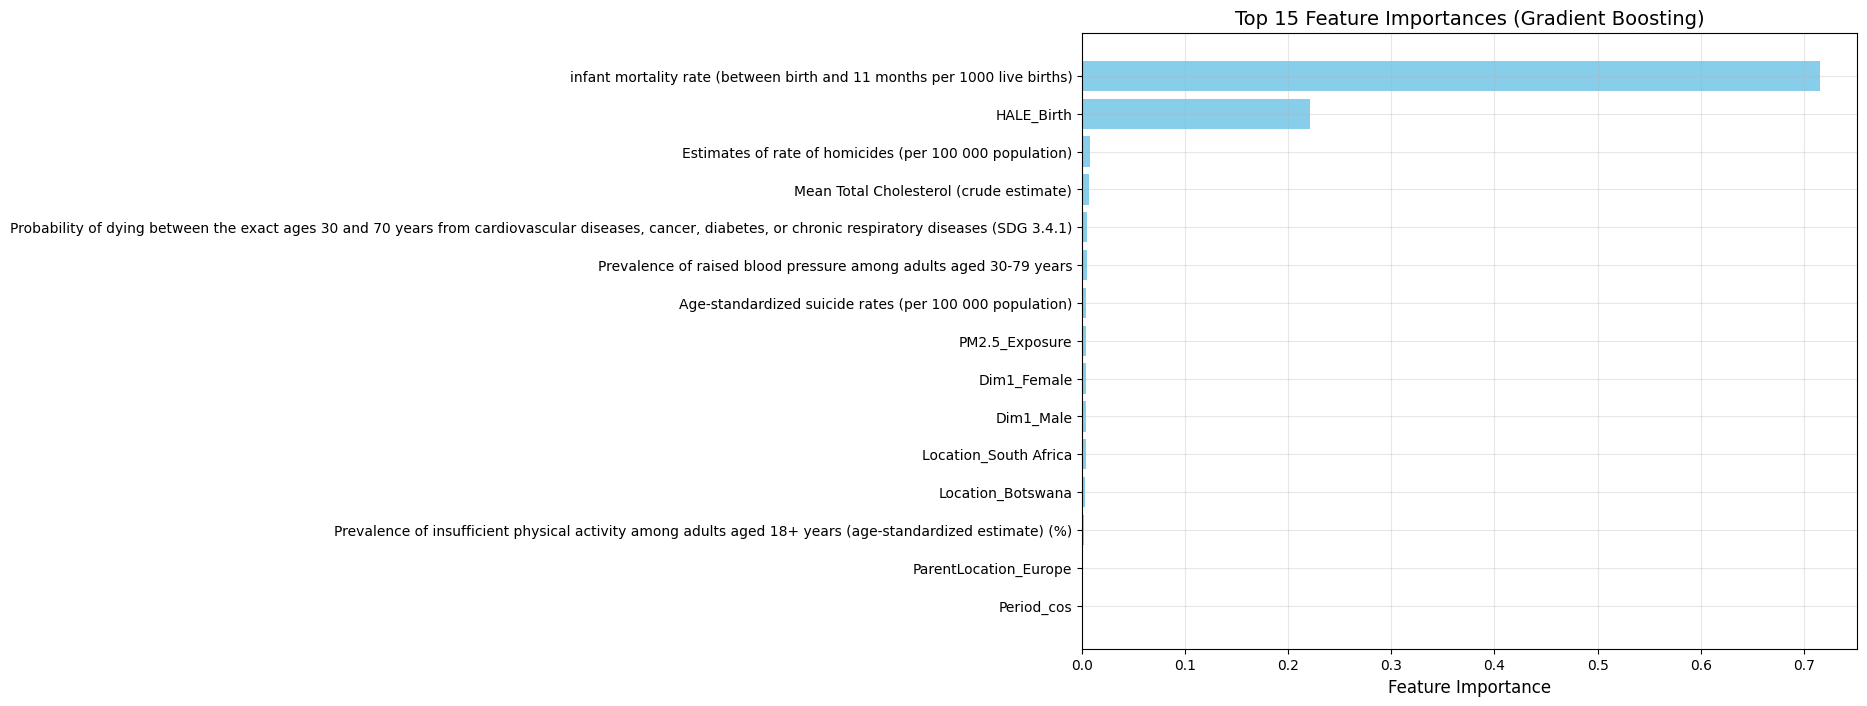


TOP 15 MOST IMPORTANT FEATURES (Gradient Boosting)
                                                                                                                                                Feature  Importance
                                                                               infant mortality rate (between birth and 11 months per 1000 live births)    0.715909
                                                                                                                                             HALE_Birth    0.220975
                                                                                                Estimates of rate of homicides (per 100 000 population)    0.007463
                                                                                                                Mean Total Cholesterol (crude estimate)    0.006616
Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respirato

In [64]:
# ============= 9. MOST IMPORTANT VARIABLES (BEST MODEL) =============

# Find best model based on Test R²
best_model_name = max(model_results, key=lambda x: model_results[x]['Test R²'])
print(f"\n🏆 Best Model: {best_model_name} (Test R² = {model_results[best_model_name]['Test R²']:.4f})")

# Extract importance from best model
if best_model_name == 'Random Forest':
    best_model = rf_model
    importance = best_model.feature_importances_
    importance_type = "Feature Importance"
elif best_model_name == 'Gradient Boosting':
    best_model = gbr_model
    importance = best_model.feature_importances_
    importance_type = "Feature Importance"
elif best_model_name == 'Ridge Regression':
    best_model = ridge_model
    importance = np.abs(best_model.coef_)
    importance_type = "|Coefficient|"
else:
    importance = None
    importance_type = "Unknown"

# Feature importance plot for BEST model
plt.figure(figsize=(10, 8))

if importance is not None:
    feature_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance
    }).sort_values(by='Importance', ascending=False)
    
    plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
    plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14)
    plt.xlabel(importance_type, fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Also print the values
    print("\n" + "="*50)
    print(f"TOP 15 MOST IMPORTANT FEATURES ({best_model_name})")
    print("="*50)
    print(feature_importance_df.head(15).to_string(index=False))
else:
    print(f"⚠️ Cannot extract feature importance for {best_model_name}")



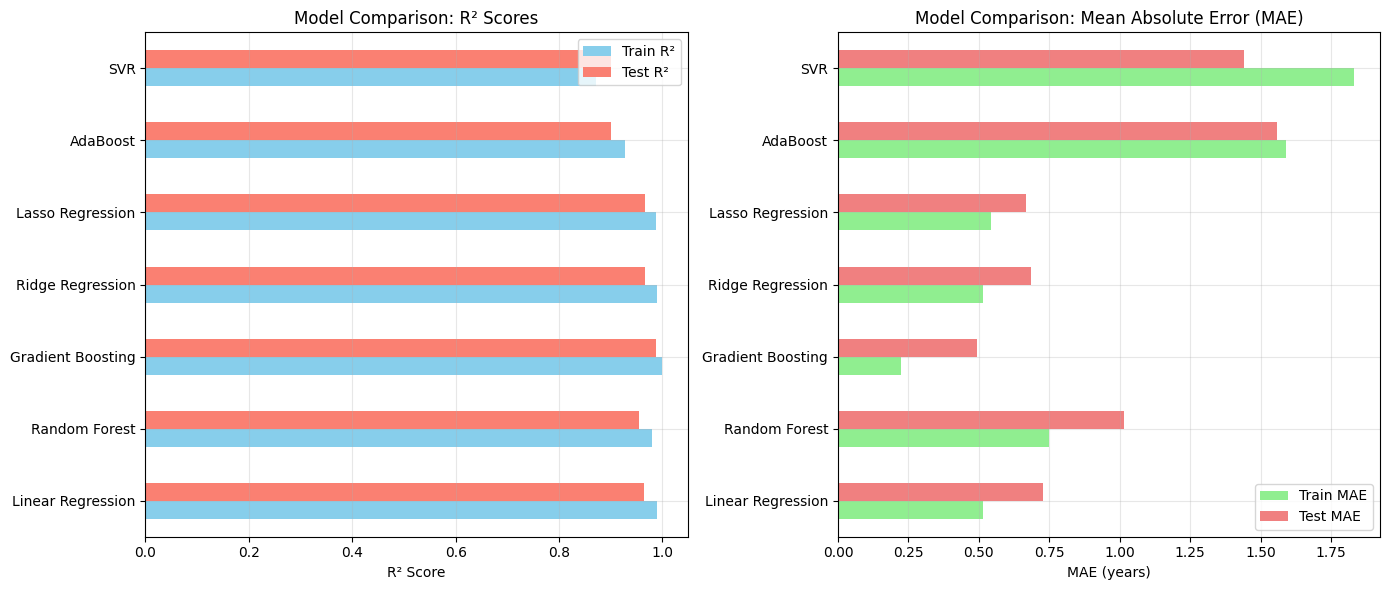

In [65]:
# ============= 10. Visualizations =============
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² comparison
comparison_df[['Train R²', 'Test R²']].plot(kind='barh', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Model Comparison: R² Scores')
axes[0].set_xlabel('R² Score')
axes[0].grid(True, alpha=0.3)

# MAE comparison
comparison_df[['Train MAE', 'Test MAE']].plot(kind='barh', ax=axes[1], color=['lightgreen', 'lightcoral'])
axes[1].set_title('Model Comparison: Mean Absolute Error (MAE)')
axes[1].set_xlabel('MAE (years)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [66]:
print("\n✅ Training and evaluation completed successfully!")


✅ Training and evaluation completed successfully!


In [67]:
import os
import joblib

# Create directories
results_dir = '../results'
os.makedirs(f'{results_dir}/tables', exist_ok=True)
os.makedirs(f'{results_dir}/figures', exist_ok=True)
os.makedirs(f'{results_dir}/models', exist_ok=True)

print("="*60)
print("SAVING RESULTS")
print("="*60)

# ============= CSV 1: Model Comparison Results =============
comparison_df.to_csv(f'{results_dir}/tables/model_results.csv')
print(f"✅ CSV 1 saved: {results_dir}/tables/model_results.csv")

# ============= CSV 2: Feature Importance =============
if 'feature_importance_df' in locals():
    feature_importance_df.to_csv(f'{results_dir}/tables/feature_importance.csv', index=False)
    print(f"✅ CSV 2 saved: {results_dir}/tables/feature_importance.csv")

# ============= Save Plots =============
# Plot 1: Feature Importance
plt.figure(figsize=(10, 8))
if 'feature_importance_df' in locals():
    plt.barh(feature_importance_df['Feature'][:15], feature_importance_df['Importance'][:15], color='skyblue')
    plt.title(f'Top 15 Feature Importances ({best_model_name})', fontsize=14)
    plt.xlabel('Importance', fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{results_dir}/figures/feature_importance.png', dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Plot 1 saved: {results_dir}/figures/feature_importance.png")

# Plot 2: Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
comparison_df[['Train R²', 'Test R²']].plot(kind='barh', ax=axes[0], color=['skyblue', 'salmon'])
axes[0].set_title('Model Comparison: R² Scores')
axes[0].set_xlabel('R² Score')
axes[0].grid(True, alpha=0.3)
comparison_df[['Train MAE', 'Test MAE']].plot(kind='barh', ax=axes[1], color=['lightgreen', 'lightcoral'])
axes[1].set_title('Model Comparison: MAE')
axes[1].set_xlabel('MAE (years)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{results_dir}/figures/model_comparison.png', dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Plot 2 saved: {results_dir}/figures/model_comparison.png")

# ============= Save Best Model =============
best_model_name = max(model_results, key=lambda x: model_results[x]['Test R²'])
if best_model_name == 'Gradient Boosting':
    joblib.dump(gbr_model, f'{results_dir}/models/best_model.pkl')
elif best_model_name == 'Random Forest':
    joblib.dump(rf_model, f'{results_dir}/models/best_model.pkl')
else:
    joblib.dump(lr_model, f'{results_dir}/models/best_model.pkl')
print(f"✅ Best model saved: {results_dir}/models/best_model.pkl")

# ============= Summary =============
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"📁 {results_dir}/")
print(f"   ├── tables/")
print(f"   │   ├── model_results.csv        (R², MAE, RMSE for all models)")
print(f"   │   └── feature_importance.csv   (top features)")
print(f"   ├── figures/")
print(f"   │   ├── feature_importance.png")
print(f"   │   └── model_comparison.png")
print(f"   └── models/")
print(f"       └── best_model.pkl")
print("="*60)
print(f"🏆 Best Model: {best_model_name}")
print(f"   Test R²:  {model_results[best_model_name]['Test R²']:.4f}")
print(f"   Test MAE: {model_results[best_model_name]['Test MAE']:.4f}")
print("="*60)
print("✅ Done!")

SAVING RESULTS
✅ CSV 1 saved: ../results/tables/model_results.csv
✅ CSV 2 saved: ../results/tables/feature_importance.csv
✅ Plot 1 saved: ../results/figures/feature_importance.png
✅ Plot 2 saved: ../results/figures/model_comparison.png
✅ Best model saved: ../results/models/best_model.pkl

FINAL RESULTS SUMMARY
📁 ../results/
   ├── tables/
   │   ├── model_results.csv        (R², MAE, RMSE for all models)
   │   └── feature_importance.csv   (top features)
   ├── figures/
   │   ├── feature_importance.png
   │   └── model_comparison.png
   └── models/
       └── best_model.pkl
🏆 Best Model: Gradient Boosting
   Test R²:  0.9867
   Test MAE: 0.4935
✅ Done!
